In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from face_dataset import process_pixels, FaceDataset

Data Loading: Read the CSV and inspected the raw pixels strings.

In [2]:
# Load the dataset
df = pd.read_csv('./data/age_gender.csv')

print(df.head())
print(df.columns)

   age  ethnicity  gender                        img_name  \
0    1          2       0  20161219203650636.jpg.chip.jpg   
1    1          2       0  20161219222752047.jpg.chip.jpg   
2    1          2       0  20161219222832191.jpg.chip.jpg   
3    1          2       0  20161220144911423.jpg.chip.jpg   
4    1          2       0  20161220144914327.jpg.chip.jpg   

                                              pixels  
0  129 128 128 126 127 130 133 135 139 142 145 14...  
1  164 74 111 168 169 171 175 182 184 188 193 199...  
2  67 70 71 70 69 67 70 79 90 103 116 132 145 155...  
3  193 197 198 200 199 200 202 203 204 205 208 21...  
4  202 205 209 210 209 209 210 211 212 214 218 21...  
Index(['age', 'ethnicity', 'gender', 'img_name', 'pixels'], dtype='str')


Preprocessing: Create a function to split, convert, and reshape strings to $48 \times 48$.

Image shape: (48, 48)


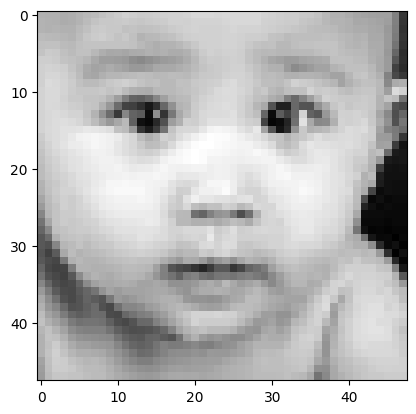

In [3]:
# Test it on the first row of the DataFrame
test_img = process_pixels(df['pixels'][0])
print(f"Image shape: {test_img.shape}")

# Visualize one to make sure it looks like a face
plt.imshow(test_img, cmap='gray')
plt.show()

Spliting: Divided the data into three distinct buckets.

In [4]:
from sklearn.model_selection import train_test_split

# 1. First split: 80% for training, 20% for a "temporary" set
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# 2. Second split: Split that 20% into two equal 10% halves (Validation and Test)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Testing rows: {len(test_df)}")

Training rows: 18964
Validation rows: 2370
Testing rows: 2371


Data pipeline: Built a custom Dataset and DataLoader for batching.

In [5]:
train_dataset = FaceDataset(train_df)
val_dataset = FaceDataset(val_df)
test_dataset = FaceDataset(test_df)

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Model Architecture

One small technical hurdle: mobilenet_v3_large expects 3-channel (RGB) images, but our data is 1-channel (Grayscale).

To fix this without changing the model's complex internal architecture, we can simply "repeat" our grayscale channel three times right before we feed it into the model.

In PyTorch, we can use .repeat(1, 3, 1, 1) on a batch of images to turn a shape of (Batch, 1, 48, 48) into (Batch, 3, 48, 48).

In the multi-task model, we will actually have three different losses running at the same time:

1. Age Loss: nn.MSELoss() (calculates the distance between numbers).

2. Gender Loss: nn.CrossEntropyLoss() (binary classification).

3. Ethnicity Loss: nn.CrossEntropyLoss() (multi-class classification).

During training, we sum these together to get a Total Loss that tells the model how it's doing across all three tasks.

In [7]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from model import FaceAnalysisModel
# from tqdm import tqdm

# # 2. Setup Device, Model, and Freezing
# # Instantiate
# device = torch.device("mps" if torch.mps.is_available() else "cpu")
# model = FaceAnalysisModel(backbone_requires_grad=True).to(device)

# # ⚖️ Define our three distinct Loss Functions
# criterion_age = nn.MSELoss()  # For the number (Age)
# criterion_gender = nn.CrossEntropyLoss()  # For the category (Gender)
# criterion_ethnicity = nn.CrossEntropyLoss()  # For the category (Ethnicity)

# # 🏎️ Optimizer (only tracking the parameters that aren't frozen)
# optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=0.001)

# # 4. Example Training Step (Inside your training loop)
# def train_one_epoch(epoch):
#     model.train()
#     total_loss = 0.0

#     for batch in tqdm(train_dataloader, desc=f'Training epoch: {epoch}'):
#         optimizer.zero_grad()

#         images, labels = batch

#         images = images.to(device)
#         # Move labels to device
#         age_targets = labels["age"].to(device).float().unsqueeze(1)
#         gender_targets = labels["gender"].to(device)
#         ethnicity_targets = labels["ethnicity"].to(device)

#         # Forward
#         out_age, out_gender, out_ethnicity = model(images)

#         # Calculate Losses
#         loss_a = criterion_age(out_age, age_targets)
#         loss_g = criterion_gender(out_gender, gender_targets)
#         loss_e = criterion_ethnicity(out_ethnicity, ethnicity_targets)

#         # Sum and Backprop
#         total_loss = loss_a + loss_g + loss_e
#         total_loss.backward()
#         optimizer.step()

#     return total_loss.item(), loss_a.item(), loss_g.item(), loss_e.item()

# @torch.no_grad
# def validate():
#     model.eval()
#     age_mae = []
#     total_samples = 0
#     correct_genders = 0
#     correct_ethnicity = 0
#     for batch in val_dataloader:
#         images, labels = batch

#         images = images.to(device)
#         # Move labels to device
#         age_targets = labels["age"].to(device).float().unsqueeze(1)
#         gender_targets = labels["gender"].to(device)
#         ethnicity_targets = labels["ethnicity"].to(device)

#         # Forward
#         out_age, out_gender, out_ethnicity = model(images)

#         # Calculate Losses
#         mae = torch.abs(age_targets - out_age).mean()
#         age_mae.append(mae.cpu())

#         correct_genders += (out_gender.argmax(dim=1) == gender_targets).sum().item()
#         correct_ethnicity += (out_ethnicity.argmax(dim=1) == ethnicity_targets).sum().item()
#         total_samples += len(out_age)
#     gender_acc = correct_genders / total_samples
#     ethnicity_acc = correct_ethnicity / total_samples
#     return np.mean(age_mae), gender_acc * 100, ethnicity_acc * 100

# epochs = 30
# for epoch in range(epochs):
#     total_loss, age_loss, gender_loss, ethinicity_loss = train_one_epoch(epoch)

#     age_mae, gender_acc, ethnicity_acc = validate()

#     print(f"Epoch: {epoch}/{epochs} | Total Loss: {total_loss:.4f} | Age Loss: {age_loss:.4f} | Gender Loss: {gender_loss:.4f} | Ethnicity Loss: {ethnicity_loss:.4f} | Val MAE, Gender Acc, Ethnicity Acc: {age_mae:.4f}, {gender_acc:.2f}, {ethnicity_acc:.2f}")


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from model import FaceAnalysisModel
from tqdm import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = FaceAnalysisModel(backbone_requires_grad=True).to(device)

criterion_age = nn.MSELoss()
criterion_gender = nn.CrossEntropyLoss()
criterion_ethnicity = nn.CrossEntropyLoss()

optimizer = optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=1e-3, weight_decay=1e-4)

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    running_age = 0.0
    running_gender = 0.0
    running_ethnicity = 0.0
    num_batches = 0

    for images, labels in tqdm(train_dataloader, desc=f"Training epoch {epoch}"):
        optimizer.zero_grad()

        images = images.to(device)
        age_targets = labels["age"].to(device).float().unsqueeze(1)
        gender_targets = labels["gender"].to(device).long()
        ethnicity_targets = labels["ethnicity"].to(device).long()

        out_age, out_gender, out_ethnicity = model(images)

        loss_a = criterion_age(out_age, age_targets)
        loss_g = criterion_gender(out_gender, gender_targets)
        loss_e = criterion_ethnicity(out_ethnicity, ethnicity_targets)

        loss = loss_a + loss_g + loss_e
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_age += loss_a.item()
        running_gender += loss_g.item()
        running_ethnicity += loss_e.item()
        num_batches += 1

    return (
        running_loss / num_batches,
        running_age / num_batches,
        running_gender / num_batches,
        running_ethnicity / num_batches,
    )

@torch.no_grad()
def validate():
    model.eval()
    age_abs_errors = []
    total_samples = 0
    correct_gender = 0
    correct_ethnicity = 0

    for images, labels in val_dataloader:
        images = images.to(device)
        age_targets = labels["age"].to(device).float().unsqueeze(1)
        gender_targets = labels["gender"].to(device).long()
        ethnicity_targets = labels["ethnicity"].to(device).long()

        out_age, out_gender, out_ethnicity = model(images)

        age_abs_errors.append(torch.abs(out_age - age_targets).mean().item())
        correct_gender += (out_gender.argmax(dim=1) == gender_targets).sum().item()
        correct_ethnicity += (out_ethnicity.argmax(dim=1) == ethnicity_targets).sum().item()
        total_samples += images.size(0)

    age_mae = float(np.mean(age_abs_errors))
    gender_acc = 100.0 * correct_gender / total_samples
    ethnicity_acc = 100.0 * correct_ethnicity / total_samples
    return age_mae, gender_acc, ethnicity_acc

epochs = 30
for epoch in range(epochs):
    train_loss, age_loss, gender_loss, ethnicity_loss = train_one_epoch(epoch)
    age_mae, gender_acc, ethnicity_acc = validate()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Age Loss: {age_loss:.4f} | Gender Loss: {gender_loss:.4f} | Ethnicity Loss: {ethnicity_loss:.4f} | "
        f"Val MAE: {age_mae:.4f} | Gender Acc: {gender_acc:.2f}% | Ethnicity Acc: {ethnicity_acc:.2f}%"
    )

Training epoch 0: 100%|██████████| 593/593 [00:41<00:00, 14.30it/s]


Epoch 1/30 | Train Loss: 183.4117 | Age Loss: 181.6566 | Gender Loss: 0.5261 | Ethnicity Loss: 1.2290 | Val MAE: 7.2421 | Gender Acc: 76.29% | Ethnicity Acc: 55.44%


Training epoch 1: 100%|██████████| 593/593 [00:39<00:00, 15.10it/s]


Epoch 2/30 | Train Loss: 98.5876 | Age Loss: 97.0156 | Gender Loss: 0.4437 | Ethnicity Loss: 1.1284 | Val MAE: 6.6735 | Gender Acc: 77.93% | Ethnicity Acc: 57.34%


Training epoch 2: 100%|██████████| 593/593 [00:39<00:00, 15.19it/s]


...

Epoch 28/30 | Train Loss: 13.3151 | Age Loss: 12.2013 | Gender Loss: 0.3005 | Ethnicity Loss: 0.8133 | Val MAE: 6.1302 | Gender Acc: 86.20% | Ethnicity Acc: 66.37%


Training epoch 28: 100%|██████████| 593/593 [00:40<00:00, 14.70it/s]


Epoch 29/30 | Train Loss: 12.2495 | Age Loss: 11.1569 | Gender Loss: 0.2943 | Ethnicity Loss: 0.7983 | Val MAE: 5.6636 | Gender Acc: 87.05% | Ethnicity Acc: 67.72%


Training epoch 29: 100%|██████████| 593/593 [00:39<00:00, 15.03it/s]


Epoch 30/30 | Train Loss: 12.8290 | Age Loss: 11.7426 | Gender Loss: 0.2925 | Ethnicity Loss: 0.7940 | Val MAE: 5.6110 | Gender Acc: 86.41% | Ethnicity Acc: 67.81%


In [9]:
torch.save(model.state_dict(), 'face_cnn.pth')

In [11]:
# Load the model again
model = FaceAnalysisModel(backbone_requires_grad=False)
model.load_state_dict(torch.load("face_cnn.pth"))
model

FaceAnalysisModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 

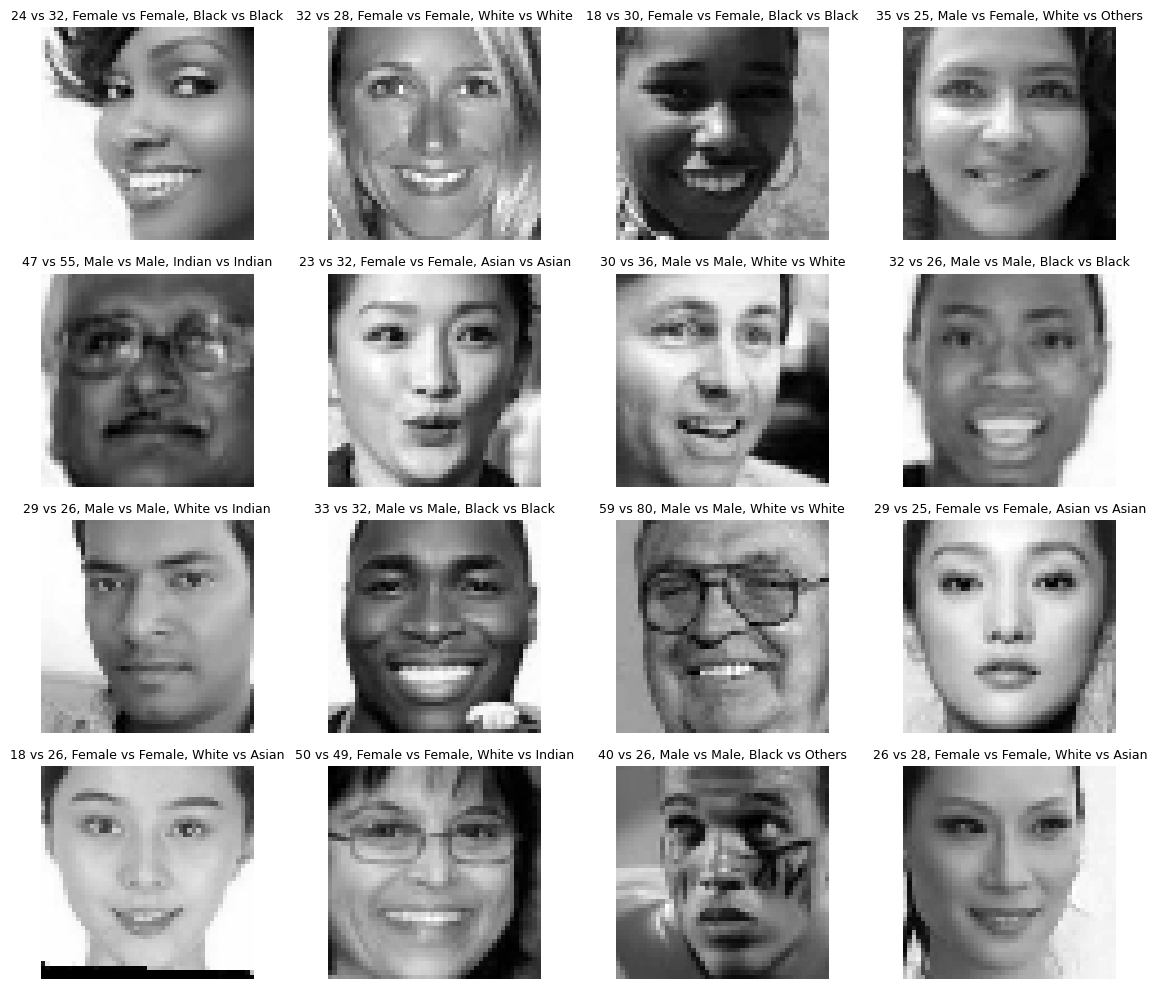

In [26]:
import matplotlib.pyplot as plt

# 1. Define the human-readable labels
genders= ["Male", "Female"]
ethnicities = ["White", "Black", "Asian", "Indian", "Others"]

# 2. Grab a single batch of images from the test loader
images, labels = next(iter(test_dataloader))

# 3. Get predictions for that batch
model.eval() # Set model to evaluation mode
preds = []
with torch.no_grad():
    outputs = model(images)
    age, gender, ethnicity = outputs
    gender = gender.argmax(dim=1)
    ethnicity = ethnicity.argmax(dim=1)
    for j in range(len(age)):
        preds.append((age[j].item(), gender[j].item(), ethnicity[j].item()))

# 4. Plot the first 6 images
plt.figure(figsize=(12, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    
    # Clean up the image for display (28x28)
    img = images[i].squeeze()
    plt.imshow(img, cmap="gray")
    
    age_pred, gender_pred, eth_pred = preds[i]
    age_label, gender_label, eth_label = labels['age'][i].item(), labels['gender'][i].item(), labels['ethnicity'][i].item()
    plt.title(f"{age_pred:.0f} vs {age_label:.0f}, {genders[gender_pred]} vs {genders[gender_label]}, {ethnicities[eth_pred]} vs {ethnicities[eth_label]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [33]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_gender_preds = []
all_gender_labels = []
all_ethnicity_preds = []
all_ethnicity_labels = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        outputs = model(images)
        age, gender, ethnicity = outputs
        gender = gender.argmax(dim=1)
        ethnicity = ethnicity.argmax(dim=1)
        
        # Move to CPU and convert to numpy for sklearn
        all_gender_preds.extend(gender.cpu().numpy())
        all_gender_labels.extend(labels['gender'].cpu().numpy())

        all_ethnicity_preds.extend(ethnicity.cpu().numpy())
        all_ethnicity_labels.extend(labels['ethnicity'].cpu().numpy())

100%|██████████| 149/149 [00:30<00:00,  4.85it/s]


In [34]:
confusion_matrix(all_gender_labels, all_gender_preds)

array([[1073,  166],
       [ 159,  973]])

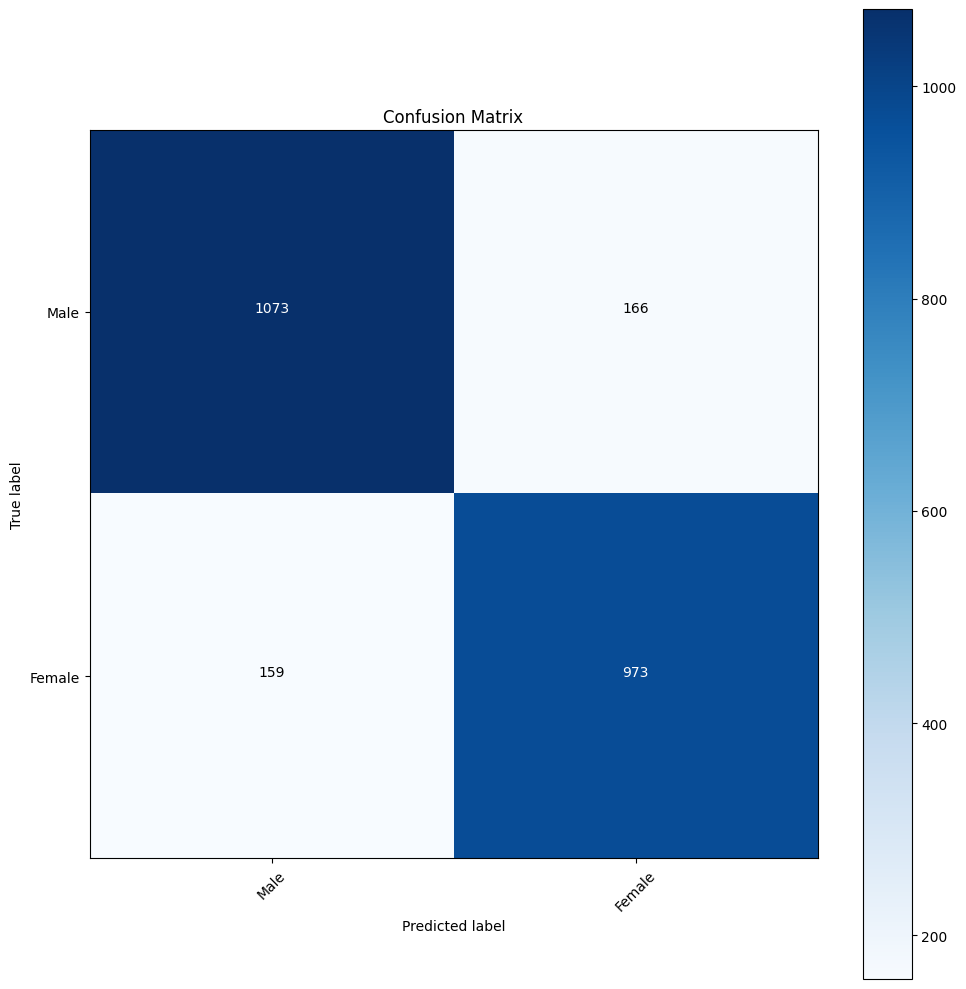

In [35]:
import itertools

def plot_confusion_matrix(cm, classes, cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title("Confusion Matrix")
    plt.colorbar()
    
    # Add labels to the axes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add the counts inside each cell
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Run the plotting function
plt.figure(figsize=(10, 10))
plot_confusion_matrix(confusion_matrix(all_gender_labels, all_gender_preds), genders)
plt.show()

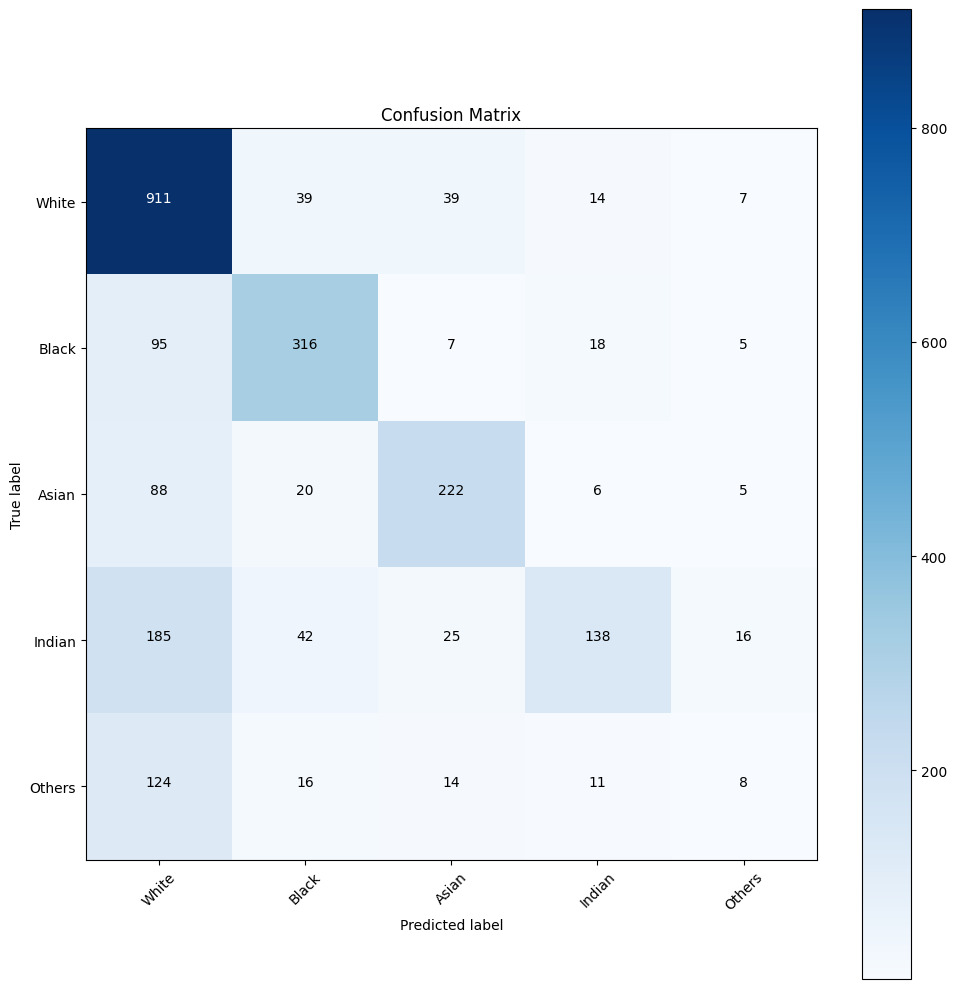

In [37]:
plt.figure(figsize=(10, 10))
plot_confusion_matrix(confusion_matrix(all_ethnicity_labels, all_ethnicity_preds), ethnicities)
plt.show()